In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [298]:
df = pd.read_csv("../data/risk_factors_cervical_cancer.csv")

df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [299]:
print("Dataset shape:", df.shape)

Dataset shape: (858, 36)


In [300]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [302]:
df = df.replace("?", np.nan)

df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [303]:
df = df.apply(pd.to_numeric)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [304]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

STDs: Time since last diagnosis       787
STDs: Time since first diagnosis      787
IUD                                   117
IUD (years)                           117
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
STDs:pelvic inflammatory disease      105
STDs:vulvo-perineal condylomatosis    105
STDs:HPV                              105
STDs:Hepatitis B                      105
STDs:HIV                              105
STDs:AIDS                             105
STDs:molluscum contagiosum            105
STDs:genital herpes                   105
STDs:syphilis                         105
STDs:vaginal condylomatosis           105
STDs:cervical condylomatosis          105
STDs:condylomatosis                   105
STDs (number)                         105
STDs                                  105
Num of pregnancies                     56
Number of sexual partners              26
Smokes (packs/year)                    13
Smokes (years)                    

In [305]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percentage

STDs: Time since last diagnosis       91.724942
STDs: Time since first diagnosis      91.724942
IUD                                   13.636364
IUD (years)                           13.636364
Hormonal Contraceptives               12.587413
Hormonal Contraceptives (years)       12.587413
STDs:pelvic inflammatory disease      12.237762
STDs:vulvo-perineal condylomatosis    12.237762
STDs:HPV                              12.237762
STDs:Hepatitis B                      12.237762
STDs:HIV                              12.237762
STDs:AIDS                             12.237762
STDs:molluscum contagiosum            12.237762
STDs:genital herpes                   12.237762
STDs:syphilis                         12.237762
STDs:vaginal condylomatosis           12.237762
STDs:cervical condylomatosis          12.237762
STDs:condylomatosis                   12.237762
STDs (number)                         12.237762
STDs                                  12.237762
Num of pregnancies                     6

In [306]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df_clean = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df_clean.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18.0,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,15.0,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34.0,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,52.0,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,4.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,46.0,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [307]:
df_clean.isnull().sum().sum()

np.int64(0)

In [308]:
## Section 2: Target Selection and Feature Preparation

# In this section, we define the prediction goal of the project. The dataset contains four diagnostic result columns: `Hinselmann`, `Schiller`, `Citology`, and `Biopsy`.

# For this project, `Biopsy` is selected as the target variable because it represents an important diagnostic outcome. The other diagnostic result columns are removed from the input features to avoid data leakage.

# The data will be separated into:

# - `X`: input features used by the model
# - `y`: target variable, which is the biopsy result

In [309]:
diagnostic_columns = ["Hinselmann", "Schiller", "Citology", "Biopsy"]

df_clean[diagnostic_columns].head()

,Hinselmann,Schiller,Citology,Biopsy
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0


In [310]:
df_clean["Biopsy"].value_counts()

Biopsy
0.0    803
1.0     55
Name: count, dtype: int64

In [311]:
df_clean["Biopsy"].value_counts(normalize=True) * 100

Biopsy
0.0    93.589744
1.0     6.410256
Name: proportion, dtype: float64

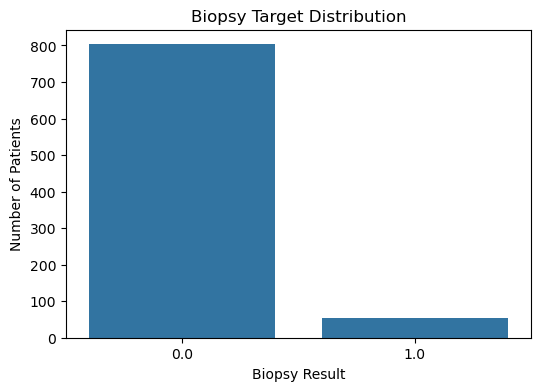

In [312]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_clean["Biopsy"])
plt.title("Biopsy Target Distribution")
plt.xlabel("Biopsy Result")
plt.ylabel("Number of Patients")
plt.show()

In [313]:
# ### Class Distribution Observation

# After selecting `Biopsy` as the target variable, we examined its distribution and found that the dataset is highly imbalanced. Approximately 93.6% of the samples belong to class `0`, while only 6.4% belong to class `1`.

# This means that negative biopsy cases are much more common than positive biopsy cases. Because of this imbalance, accuracy alone is not a reliable evaluation metric. In the later modeling stages, more informative metrics such as precision, recall, F1-score, ROC-AUC, and the confusion matrix will be used. Stratified splitting and class balancing techniques will also be considered.

In [314]:
# ## Section 3: Train-Test Split

# In this section, the dataset was divided into training and testing sets. The training set is used to train the machine learning models, while the testing set is used to evaluate how well the models perform on unseen data.

# An 80/20 split was used, where 80% of the data was used for training and 20% was used for testing. The parameter `random_state=42` was used to make the split reproducible.

# Since the target variable `Biopsy` is highly imbalanced, `stratify=y` was used during the split. This ensures that both the training and testing sets keep approximately the same class distribution as the original dataset.

In [315]:
target = "Biopsy"

X = df_clean.drop(columns=["Hinselmann", "Schiller", "Citology", "Biopsy"])
y = df_clean[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (858, 32)
Target shape: (858,)


In [316]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (686, 32)
X_test: (172, 32)
y_train: (686,)
y_test: (172,)


In [317]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced")

In [318]:
# ## Section 4: Baseline Model Training and Evaluation

# In this section, several baseline classification models are trained and evaluated. Since the target variable `Biopsy` is binary, this is a binary classification problem.

# The models used in this section are:

# - Logistic Regression
# - Decision Tree
# - Random Forest
# - Support Vector Machine
# - K-Nearest Neighbors

# These models are trained using the same training set and evaluated using the same test set. Because the dataset is highly imbalanced, accuracy alone is not enough. Therefore, precision, recall, F1-score, ROC-AUC, and the confusion matrix are used to evaluate model performance.

# Models that support class balancing use `class_weight="balanced"` to give more importance to the minority class.

In [319]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [320]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(class_weight="balanced", probability=True, random_state=42))
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}

In [321]:
results = []

for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predict class labels
    y_pred = model.predict(X_test)
    
    # Predict probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = None
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.790698,0.068966,0.181818,0.100000,0.596273
1,Decision Tree,0.912791,0.166667,0.090909,0.117647,0.530209
2,Random Forest,0.936047,0.500000,0.090909,0.153846,0.682383
3,SVM,0.860465,0.000000,0.000000,0.000000,0.659514
4,KNN,0.924419,0.000000,0.000000,0.000000,0.625918


In [322]:
results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.936047,0.500000,0.090909,0.153846,0.682383
1,Decision Tree,0.912791,0.166667,0.090909,0.117647,0.530209
0,Logistic Regression,0.790698,0.068966,0.181818,0.100000,0.596273
3,SVM,0.860465,0.000000,0.000000,0.000000,0.659514
4,KNN,0.924419,0.000000,0.000000,0.000000,0.625918


In [323]:
# ### Baseline Model Results Interpretation

# Several baseline classification models were trained and evaluated using the same train-test split. Since the dataset is highly imbalanced, accuracy alone was not considered enough to judge model performance.

# The results show that some models, such as SVM and KNN, achieved relatively high accuracy but had a recall and F1-score of 0 for the positive class. This means they failed to correctly detect positive biopsy cases, which is a major issue in a medical prediction problem.

# Random Forest achieved the best baseline F1-score and ROC-AUC, making it the strongest baseline model overall. Logistic Regression achieved the highest recall, meaning it detected more positive biopsy cases compared to the other models, although its precision was low.

# Based on these results, Random Forest and Logistic Regression will be important candidates for further improvement using hyperparameter tuning.

In [324]:
# ## Section 5: Detailed Model Evaluation

# In this section, the baseline models are evaluated in more detail using classification reports and confusion matrices.

# The classification report shows precision, recall, and F1-score for each class separately. This is important because the dataset is imbalanced, and we need to check how well the models detect the minority class, which is the positive biopsy class.

# The confusion matrix shows the number of correct and incorrect predictions for each class. It helps us understand how many positive biopsy cases were correctly detected and how many were missed.

In [325]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.94      0.83      0.88       161
         1.0       0.07      0.18      0.10        11

    accuracy                           0.79       172
   macro avg       0.50      0.51      0.49       172
weighted avg       0.88      0.79      0.83       172

Decision Tree
              precision    recall  f1-score   support

         0.0       0.94      0.97      0.95       161
         1.0       0.17      0.09      0.12        11

    accuracy                           0.91       172
   macro avg       0.55      0.53      0.54       172
weighted avg       0.89      0.91      0.90       172

Random Forest
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97       161
         1.0       0.50      0.09      0.15        11

    accuracy                           0.94       172
   macro avg       0.72      0.54      0.56       172
weighted avg       0.91   

In [326]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    print("=" * 40)
    print(model_name)
    print(cm)

Logistic Regression
[[134  27]
 [  9   2]]
Decision Tree
[[156   5]
 [ 10   1]]
Random Forest
[[160   1]
 [ 10   1]]
SVM
[[148  13]
 [ 11   0]]
KNN
[[159   2]
 [ 11   0]]


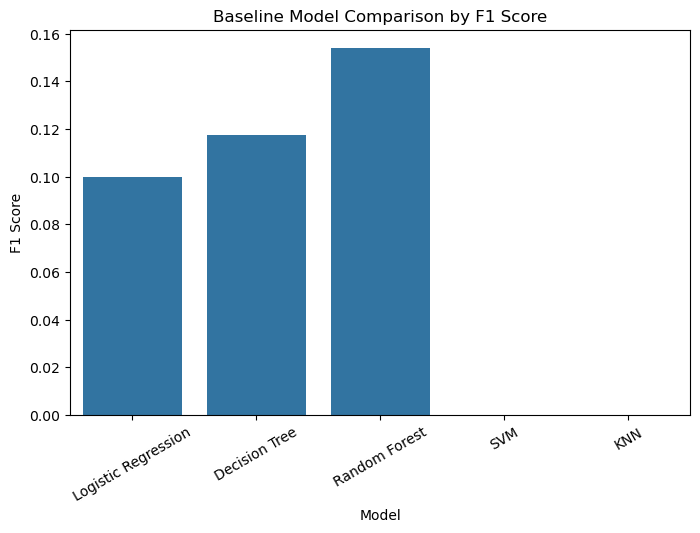

In [327]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="F1 Score")
plt.title("Baseline Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.show()

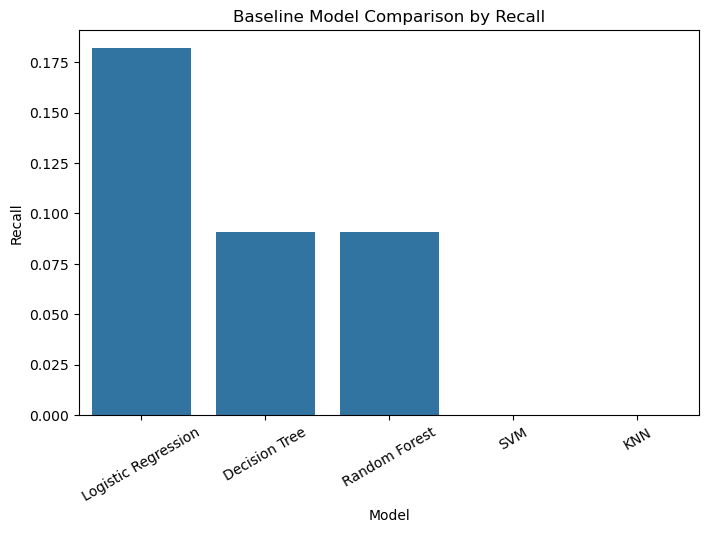

In [328]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Recall")
plt.title("Baseline Model Comparison by Recall")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=30)
plt.show()

In [329]:
# ### Detailed Evaluation Interpretation

# The detailed evaluation shows that the dataset imbalance strongly affects model performance. Although some models achieved high accuracy, they failed to detect positive biopsy cases effectively.

# Logistic Regression achieved the highest recall among the baseline models, correctly detecting 2 out of 11 positive biopsy cases. However, it also produced many false positives, resulting in low precision.

# Random Forest achieved the highest F1-score and precision among the baseline models. It made only one false positive prediction, but it detected only 1 out of 11 positive biopsy cases, meaning its recall was low.

# SVM and KNN failed to detect any positive biopsy cases in the baseline evaluation, giving them a recall and F1-score of 0 for the positive class.

# Based on these results, Random Forest and Logistic Regression are selected as the main candidates for hyperparameter tuning. Random Forest is chosen because it has the best F1-score and precision, while Logistic Regression is chosen because it has the best recall.

In [330]:
# ## Section 6: Hyperparameter Tuning

# In this section, hyperparameter tuning is performed to improve the performance of the selected baseline models. The main goal is to improve the models' ability to detect positive biopsy cases while maintaining a reasonable balance between precision and recall.

# GridSearchCV will be used to test different combinations of hyperparameters. Since the dataset is imbalanced, the models will be evaluated mainly using F1-score and recall instead of accuracy alone.

In [331]:
from sklearn.model_selection import GridSearchCV

In [332]:
rf_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best Cross-Validation F1 Score:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best Cross-Validation F1 Score:
0.3348062463851937


In [333]:
# ### Random Forest Hyperparameter Tuning Result

# GridSearchCV was used to tune the Random Forest model by testing different combinations of hyperparameters. The model was evaluated using F1-score because the dataset is highly imbalanced and accuracy alone is not reliable.

# The best parameters found were:

# - `n_estimators = 300`
# - `max_depth = 10`
# - `min_samples_split = 10`
# - `min_samples_leaf = 1`

# The best cross-validation F1-score was approximately `0.335`. This means that, during cross-validation on the training data, this parameter combination produced the best balance between precision and recall among the tested Random Forest configurations.

# The next step is to evaluate this tuned Random Forest model on the test set to check whether it performs better on unseen data.

In [334]:
best_rf_model = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test)

print("Tuned Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf_tuned, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_rf_tuned, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

Tuned Random Forest Results
Accuracy: 0.9186046511627907
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.96       161
         1.0       0.00      0.00      0.00        11

    accuracy                           0.92       172
   macro avg       0.47      0.49      0.48       172
weighted avg       0.88      0.92      0.90       172


Confusion Matrix:
[[158   3]
 [ 11   0]]


In [335]:
# ### Tuned Random Forest Evaluation

# After hyperparameter tuning, the best Random Forest model was evaluated on the test set. Although the model achieved an accuracy of approximately 91.9%, it failed to correctly identify any positive biopsy cases.

# The confusion matrix showed that the model correctly predicted most negative cases but missed all 11 positive cases in the test set. As a result, the precision, recall, and F1-score for the positive class were all 0.

# This demonstrates that accuracy is misleading for this imbalanced dataset. Even though the tuned Random Forest performed well on the majority class, it did not perform well for the minority class, which is the most important class in this medical prediction problem.

In [336]:
from sklearn.model_selection import GridSearchCV

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

log_reg_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

log_reg_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(log_reg_grid.best_params_)

print("Best Cross-Validation Recall Score:")
print(log_reg_grid.best_score_)

Best Logistic Regression Parameters:
{'model__C': 0.001, 'model__solver': 'liblinear'}
Best Cross-Validation Recall Score:
0.5416666666666666


In [337]:
# ### Logistic Regression Hyperparameter Tuning Result

# GridSearchCV was used to tune the Logistic Regression model. The model was placed inside a pipeline with `StandardScaler` because Logistic Regression is sensitive to feature scaling.

# Since the dataset is highly imbalanced and the project is related to medical prediction, the tuning process used recall as the scoring metric. Recall was chosen because it measures how many actual positive biopsy cases the model can correctly detect.

# The best parameters found were:

# - `C = 0.001`
# - `solver = liblinear`

# The best cross-validation recall score was approximately `0.542`, meaning that during cross-validation the tuned Logistic Regression model detected about 54.2% of the positive biopsy cases. This suggests that tuning improved the model's ability to identify the minority class compared to the baseline Logistic Regression.

In [338]:
best_log_reg_model = log_reg_grid.best_estimator_

y_pred_log_reg_tuned = best_log_reg_model.predict(X_test)

print("Tuned Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg_tuned))
print("Precision:", precision_score(y_test, y_pred_log_reg_tuned, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_log_reg_tuned, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_log_reg_tuned, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg_tuned, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg_tuned))

Tuned Logistic Regression Results
Accuracy: 0.7674418604651163
Precision: 0.10810810810810811
Recall: 0.36363636363636365
F1 Score: 0.16666666666666666

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.80      0.86       161
         1.0       0.11      0.36      0.17        11

    accuracy                           0.77       172
   macro avg       0.53      0.58      0.52       172
weighted avg       0.89      0.77      0.82       172


Confusion Matrix:
[[128  33]
 [  7   4]]


In [339]:
# ### Tuned Logistic Regression Evaluation

# The tuned Logistic Regression model was evaluated on the test set using accuracy, precision, recall, F1-score, classification report, and confusion matrix.

# The model achieved an accuracy of approximately 76.7%, precision of 10.8%, recall of 36.4%, and F1-score of 16.7%. Although the accuracy is lower than some other models, the tuned Logistic Regression model detected more positive biopsy cases than the previous models.

# The confusion matrix showed that the model correctly identified 4 out of 11 positive biopsy cases. However, it also produced 33 false positives, which explains the low precision.

# Since this is a medical prediction problem, recall is especially important because missing positive cases can be risky. Therefore, the tuned Logistic Regression model is currently considered one of the strongest candidates because it achieved the best recall and F1-score among the models tested so far.

In [340]:
# ### SVM Hyperparameter Tuning

# Support Vector Machine was also tuned because it is suitable for binary classification and can perform well on small datasets. Since SVM is sensitive to feature scaling, it is placed inside a pipeline with `StandardScaler`.

# GridSearchCV is used to test different values for `C`, `kernel`, and `gamma`. Because the dataset is imbalanced and detecting positive biopsy cases is important, recall is used as the scoring metric.

In [341]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(class_weight="balanced", probability=True, random_state=42))
])

svm_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("Best Cross-Validation Recall Score:")
print(svm_grid.best_score_)

Best SVM Parameters:
{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best Cross-Validation Recall Score:
0.5638888888888889


In [342]:
best_svm_model = svm_grid.best_estimator_

y_pred_svm_tuned = best_svm_model.predict(X_test)

print("Tuned SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_tuned))
print("Precision:", precision_score(y_test, y_pred_svm_tuned, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_svm_tuned, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_svm_tuned, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_tuned, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm_tuned))

Tuned SVM Results
Accuracy: 0.7906976744186046
Precision: 0.12121212121212122
Recall: 0.36363636363636365
F1 Score: 0.18181818181818182

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.82      0.88       161
         1.0       0.12      0.36      0.18        11

    accuracy                           0.79       172
   macro avg       0.54      0.59      0.53       172
weighted avg       0.90      0.79      0.84       172


Confusion Matrix:
[[132  29]
 [  7   4]]


In [343]:
# ### Tuned SVM Evaluation

# The SVM model was tuned using GridSearchCV with recall as the scoring metric. Since SVM is sensitive to feature scaling, it was placed inside a pipeline with `StandardScaler`.

# The best parameters found were:

# - `C = 0.1`
# - `kernel = rbf`
# - `gamma = scale`

# The best cross-validation recall score was approximately `0.564`, which means that during cross-validation, the model detected about 56.4% of positive biopsy cases.

# When evaluated on the test set, the tuned SVM achieved an accuracy of approximately 79.1%, precision of 12.1%, recall of 36.4%, and F1-score of 18.2%.

# The confusion matrix showed that the model correctly detected 4 out of 11 positive biopsy cases and missed 7. Compared to tuned Logistic Regression, tuned SVM achieved the same recall but produced fewer false positives, resulting in a better F1-score.

# Based on these results, tuned SVM is currently the best-performing model among the tuned models.

In [344]:
# ## Section 7: Final Model Comparison

# In this section, the baseline and tuned models are compared in one final table. The goal is to identify which model performs best based on recall, F1-score, precision, and overall behavior on the imbalanced dataset.

# Since this is a medical classification problem, recall is especially important because it shows how many positive biopsy cases were detected. However, F1-score is also considered because it balances recall and precision.

In [345]:
final_results = []

def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

final_results.append(evaluate_model("Baseline Logistic Regression", models["Logistic Regression"], X_test, y_test))
final_results.append(evaluate_model("Tuned Logistic Regression", best_log_reg_model, X_test, y_test))

final_results.append(evaluate_model("Baseline Random Forest", models["Random Forest"], X_test, y_test))
final_results.append(evaluate_model("Tuned Random Forest", best_rf_model, X_test, y_test))

final_results.append(evaluate_model("Baseline SVM", models["SVM"], X_test, y_test))
final_results.append(evaluate_model("Tuned SVM", best_svm_model, X_test, y_test))

final_results_df = pd.DataFrame(final_results)

final_results_df

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
0,Baseline Logistic Regression,0.790698,0.068966,0.181818,0.100000,"[[134, 27], [9, 2]]"
1,Tuned Logistic Regression,0.767442,0.108108,0.363636,0.166667,"[[128, 33], [7, 4]]"
2,Baseline Random Forest,0.936047,0.500000,0.090909,0.153846,"[[160, 1], [10, 1]]"
3,Tuned Random Forest,0.918605,0.000000,0.000000,0.000000,"[[158, 3], [11, 0]]"
4,Baseline SVM,0.860465,0.000000,0.000000,0.000000,"[[148, 13], [11, 0]]"
5,Tuned SVM,0.790698,0.121212,0.363636,0.181818,"[[132, 29], [7, 4]]"


In [346]:
final_results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
5,Tuned SVM,0.790698,0.121212,0.363636,0.181818,"[[132, 29], [7, 4]]"
1,Tuned Logistic Regression,0.767442,0.108108,0.363636,0.166667,"[[128, 33], [7, 4]]"
2,Baseline Random Forest,0.936047,0.500000,0.090909,0.153846,"[[160, 1], [10, 1]]"
0,Baseline Logistic Regression,0.790698,0.068966,0.181818,0.100000,"[[134, 27], [9, 2]]"
3,Tuned Random Forest,0.918605,0.000000,0.000000,0.000000,"[[158, 3], [11, 0]]"
4,Baseline SVM,0.860465,0.000000,0.000000,0.000000,"[[148, 13], [11, 0]]"


In [347]:
final_results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,Confusion Matrix
1,Tuned Logistic Regression,0.767442,0.108108,0.363636,0.166667,"[[128, 33], [7, 4]]"
5,Tuned SVM,0.790698,0.121212,0.363636,0.181818,"[[132, 29], [7, 4]]"
0,Baseline Logistic Regression,0.790698,0.068966,0.181818,0.100000,"[[134, 27], [9, 2]]"
2,Baseline Random Forest,0.936047,0.500000,0.090909,0.153846,"[[160, 1], [10, 1]]"
3,Tuned Random Forest,0.918605,0.000000,0.000000,0.000000,"[[158, 3], [11, 0]]"
4,Baseline SVM,0.860465,0.000000,0.000000,0.000000,"[[148, 13], [11, 0]]"


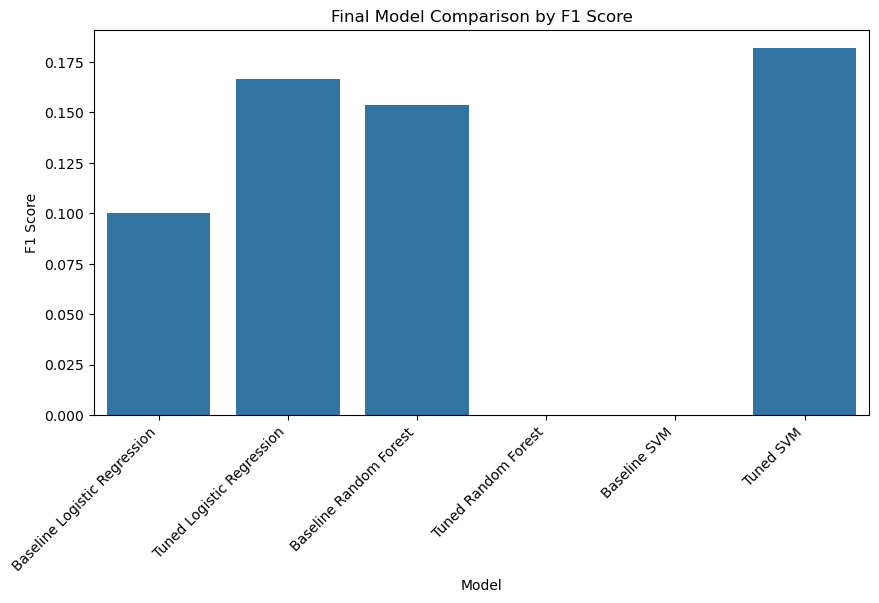

In [348]:
plt.figure(figsize=(10, 5))
sns.barplot(data=final_results_df, x="Model", y="F1 Score")
plt.title("Final Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=45, ha="right")
plt.show()

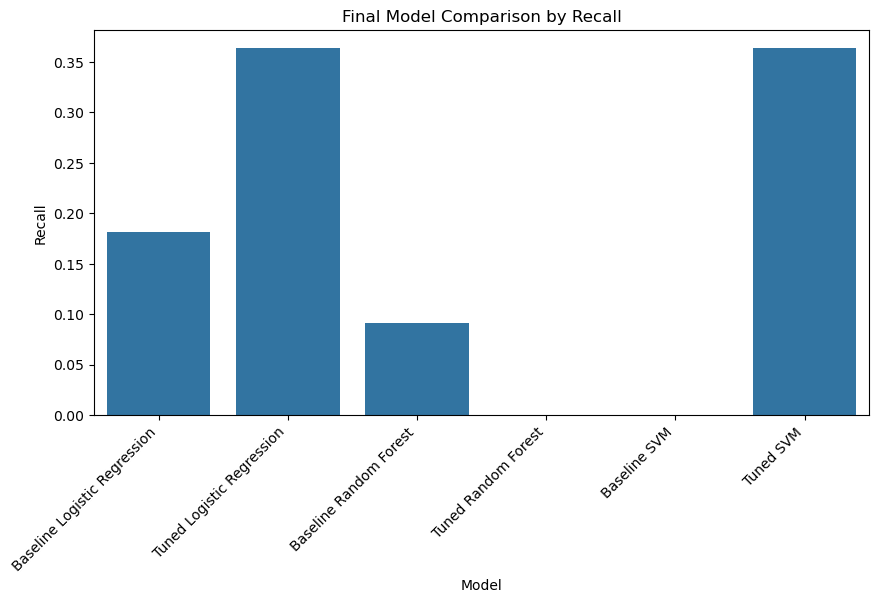

In [349]:
plt.figure(figsize=(10, 5))
sns.barplot(data=final_results_df, x="Model", y="Recall")
plt.title("Final Model Comparison by Recall")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=45, ha="right")
plt.show()

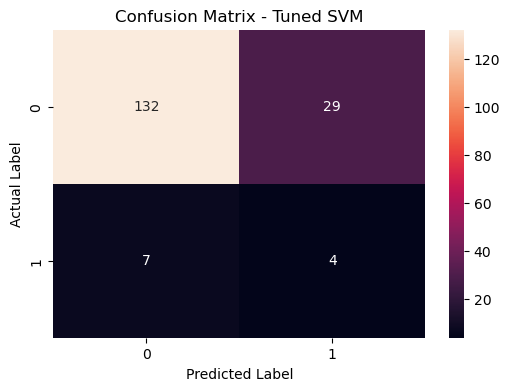

In [350]:
cm_svm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm_tuned, annot=True, fmt="d")
plt.title("Confusion Matrix - Tuned SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
# ### Final Model Comparison Interpretation

# After evaluating the baseline and tuned models, the results show that accuracy alone is not a reliable metric for this project because the dataset is highly imbalanced. Some models achieved high accuracy but failed to detect positive biopsy cases.

# Baseline Random Forest achieved the highest accuracy, but its recall was very low, meaning it missed most positive biopsy cases. Tuned Random Forest and baseline SVM failed to detect any positive cases.

# Tuned Logistic Regression and Tuned SVM achieved the highest recall, both detecting 4 out of 11 positive biopsy cases. However, tuned SVM achieved a higher F1-score and slightly better precision than tuned Logistic Regression.

# Therefore, tuned SVM is selected as the best final model because it provides the best balance between recall and precision while achieving the highest F1-score among the tested models.